In [1]:
import shap

In [2]:
from biological_age.utils.model_io import load_model


In [3]:
from pathlib import Path

MODELS_DIR = Path("../models/tuned")

In [4]:
xgb_pipeline = load_model(
    MODELS_DIR / "xgb_pipeline_v1.pkl"
)

Model loaded from: ../models/tuned/xgb_pipeline_v1.pkl


In [5]:
print(type(xgb_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [6]:
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## Recreate the same train/test split

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
from biological_age.split.train_test_split import create_train_test_split

In [9]:
from biological_age.data.load_data import load_processed_dataset

df = load_processed_dataset()

print(df.shape)

df.head()

(36992, 28)


,sex,age_years,albumin,blood_urea_nitrogen,creatinine,uric_acid,hba1c_percent,total_cholesterol,hdl_cholesterol,triglycerides,...,red_cell_distribution_width,platelet_count,calcium,sodium_si,potassium_si,phosphorus,total_bilirubin,total_protein,globulin,ggt_si
0,1.0,22.0,4.8,14.0,0.91,4.9,5.1,168.0,41.0,87.0,...,11.8,223.0,9.6,137.0,3.9,3.3,0.6,7.6,2.8,14.0
1,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.4,259.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,14.0,4.0,16.0,0.65,5.8,5.5,158.0,44.0,64.0,...,12.6,259.0,9.1,137.0,3.8,5.0,0.4,7.0,3.0,8.0
3,2.0,44.0,3.7,5.0,0.89,4.5,4.9,196.0,28.0,71.0,...,14.1,297.0,9.2,138.0,4.3,3.2,0.3,6.0,2.3,18.0
4,2.0,14.0,4.1,12.0,0.50,5.8,5.9,165.0,63.0,87.0,...,12.9,257.0,9.7,139.0,4.0,4.3,0.5,6.9,2.8,20.0


In [10]:
TARGET = "age_years"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [11]:
X_train, X_test, y_train, y_test = create_train_test_split(
    X,
    y,
)

In [12]:
predictions = xgb_pipeline.predict(X_test)

print(predictions[:5])
print(f"Number of predictions: {len(predictions)}")

[30.272402  64.9378    63.585163   7.00157    3.3988583]
Number of predictions: 7399


In [13]:
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [14]:
preprocessor = xgb_pipeline.named_steps["preprocessor"]

model = xgb_pipeline.named_steps["model"]

In [15]:
print(type(preprocessor))
print(type(model))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBRegressor'>


In [16]:
print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['albumin', 'blood_urea_nitrogen',
                                  'creatinine', 'uric_acid', 'hba1c_percent',
                                  'total_cholesterol', 'hdl_cholesterol',
                                  'triglycerides', 'white_blood_cell_count',
                                  'lymphocyte_percent', 'monocyte_percent',
                                  'neutrophil_percent', 'red_blood_cell_count',
                                  'hemoglobin', 'hematocrit',
                                  'mean_corpuscular_volume',
                                  'red_cell_distribution_width',
                                  'platelet_count', 'calcium', 'sodium_si',
            

In [17]:
X_test_transformed = preprocessor.transform(X_test)

print(X_test_transformed.shape)

(7399, 27)


In [18]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)
print(f"\nNumber of features: {len(feature_names)}")

['numeric__albumin' 'numeric__blood_urea_nitrogen' 'numeric__creatinine'
 'numeric__uric_acid' 'numeric__hba1c_percent'
 'numeric__total_cholesterol' 'numeric__hdl_cholesterol'
 'numeric__triglycerides' 'numeric__white_blood_cell_count'
 'numeric__lymphocyte_percent' 'numeric__monocyte_percent'
 'numeric__neutrophil_percent' 'numeric__red_blood_cell_count'
 'numeric__hemoglobin' 'numeric__hematocrit'
 'numeric__mean_corpuscular_volume' 'numeric__red_cell_distribution_width'
 'numeric__platelet_count' 'numeric__calcium' 'numeric__sodium_si'
 'numeric__potassium_si' 'numeric__phosphorus' 'numeric__total_bilirubin'
 'numeric__total_protein' 'numeric__globulin' 'numeric__ggt_si'
 'categorical__sex']

Number of features: 27


In [19]:
import pandas as pd

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index,
)

X_test_transformed.head()

,numeric__albumin,numeric__blood_urea_nitrogen,numeric__creatinine,numeric__uric_acid,numeric__hba1c_percent,numeric__total_cholesterol,numeric__hdl_cholesterol,numeric__triglycerides,numeric__white_blood_cell_count,numeric__lymphocyte_percent,...,numeric__platelet_count,numeric__calcium,numeric__sodium_si,numeric__potassium_si,numeric__phosphorus,numeric__total_bilirubin,numeric__total_protein,numeric__globulin,numeric__ggt_si,categorical__sex
9550,2.415756,1.876061,0.439344,1.105111,-0.496748,-0.408698,0.682072,-0.243148,-0.692887,0.373125,...,-0.551946,2.183763,0.607704,-0.684741,0.374224,2.386236,0.804294,-1.071884,-0.259320,1.0
7112,0.229944,0.891670,0.618697,1.184868,-0.183499,1.086572,-0.288130,-0.273062,-0.480014,-1.148944,...,-0.959263,-0.895833,-1.273248,0.611833,0.009619,-0.207692,-1.429183,-1.575273,0.338328,1.0
9545,0.229944,0.694792,0.567453,0.865839,1.173915,-1.903968,-1.535532,1.761067,0.493117,-0.885870,...,0.713647,0.028046,0.137466,0.611833,-2.178013,-0.578254,-0.932855,-1.071884,0.078481,1.0
10261,-0.082314,-0.092721,-0.098714,-0.091249,-0.183499,-0.082457,0.058371,-0.213235,0.249834,-0.575819,...,0.888212,0.028046,0.137466,-0.036454,0.009619,-0.207692,0.059802,-0.065107,-0.181366,1.0
9876,-0.082314,-0.092721,-0.098714,-0.091249,-0.183499,-0.082457,-0.149529,-0.213235,-0.480014,1.669701,...,0.684553,0.028046,0.137466,-0.036454,0.009619,-0.207692,0.059802,-0.065107,-0.181366,1.0


In [20]:
explainer = shap.TreeExplainer(model)

In [21]:
shap_values = explainer.shap_values(X_test_transformed)

In [22]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(7399, 27)


In [23]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_transformed,
    feature_names=X_test_transformed.columns,
)

In [24]:
print(type(shap_explanation))

<class 'shap._explanation.Explanation'>


## Shap Beeswarm Plot

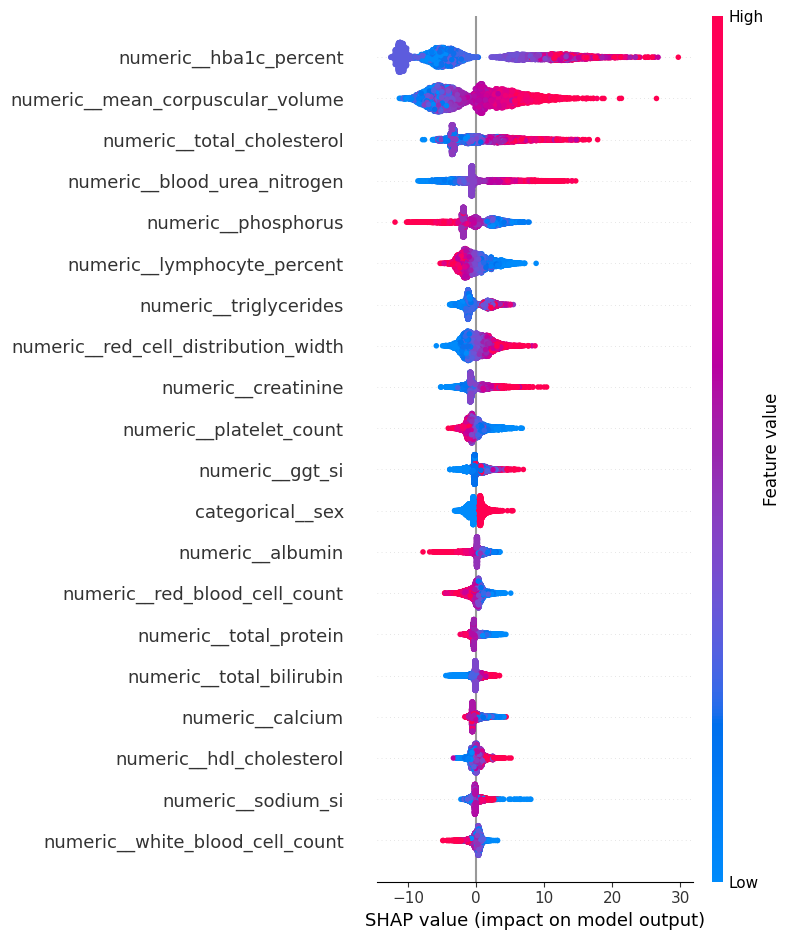

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    max_display=20,
    show=False,
)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Shap Bar Plot 

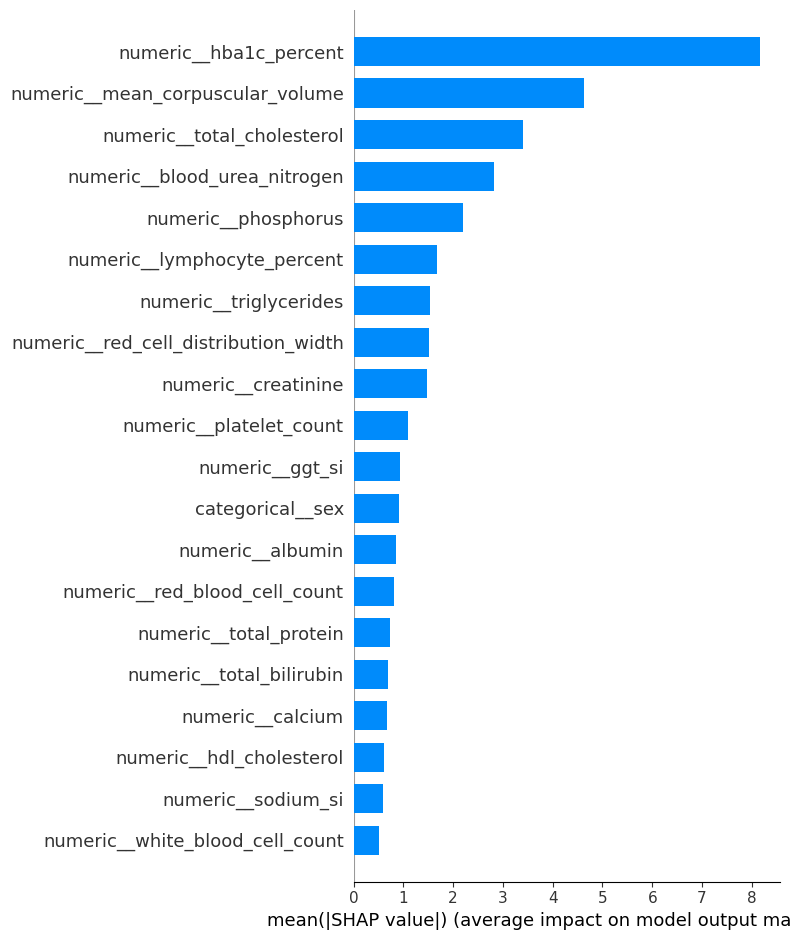

In [26]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    plot_type="bar",
    max_display=20,
    show=False,
)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/shap_bar.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Shap Dependence Plot

In [27]:
top_features = [
    "numeric__hba1c_percent",
    "numeric__mean_corpuscular_volume",
    "numeric__total_cholesterol",
    "numeric__blood_urea_nitrogen",
    "numeric__phosphorus",
]

<Figure size 800x600 with 0 Axes>

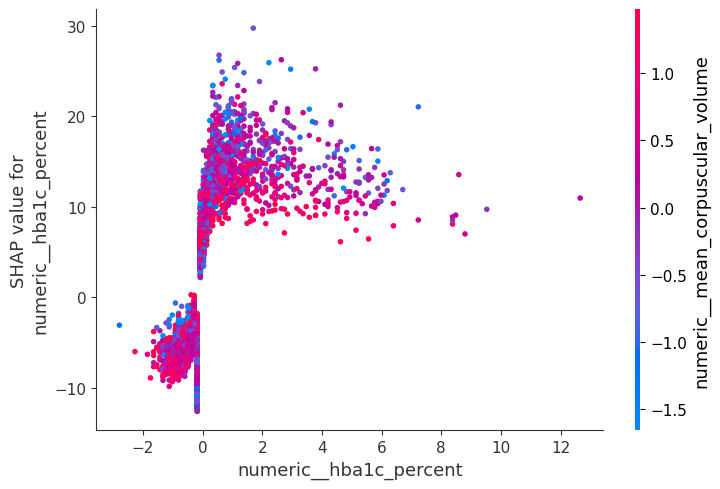

<Figure size 800x600 with 0 Axes>

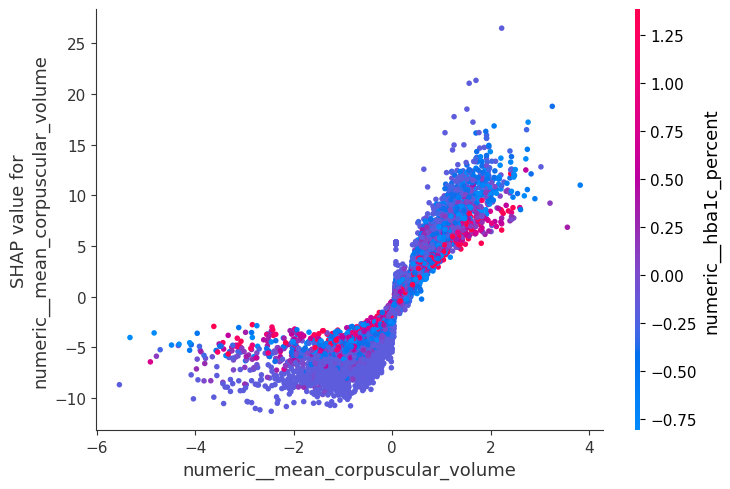

<Figure size 800x600 with 0 Axes>

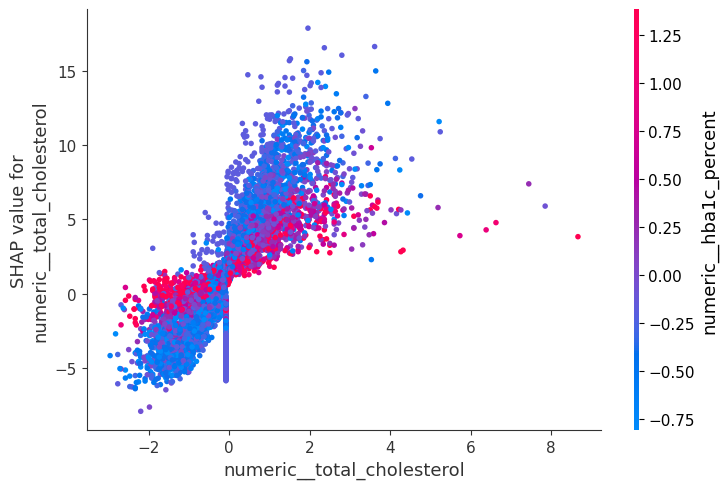

<Figure size 800x600 with 0 Axes>

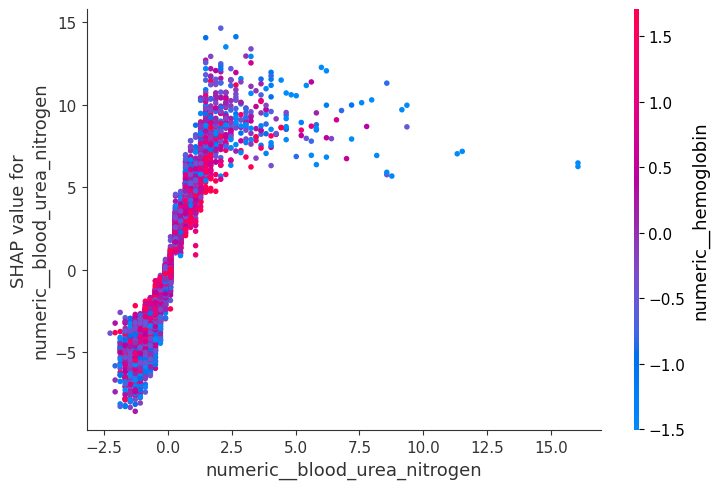

<Figure size 800x600 with 0 Axes>

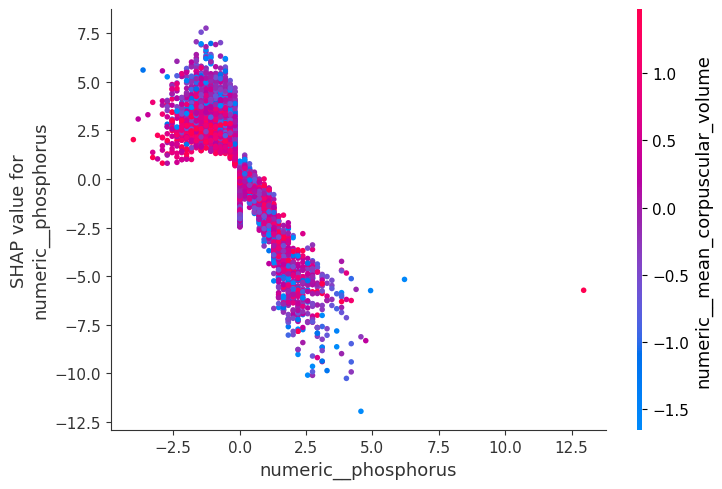

In [28]:
import matplotlib.pyplot as plt

for feature in top_features:

    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        feature,
        shap_values,
        X_test_transformed,
        interaction_index="auto",
        show=False,
    )

    plt.tight_layout()

    plt.savefig(
        f"../outputs/plots/{feature}_dependence.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## Shap WaterFall Plot 

In [29]:
print(explainer.expected_value)

35.68954


In [30]:
sample_idx = 0

waterfall_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed.iloc[sample_idx].values,
    feature_names=X_test_transformed.columns.tolist(),
)

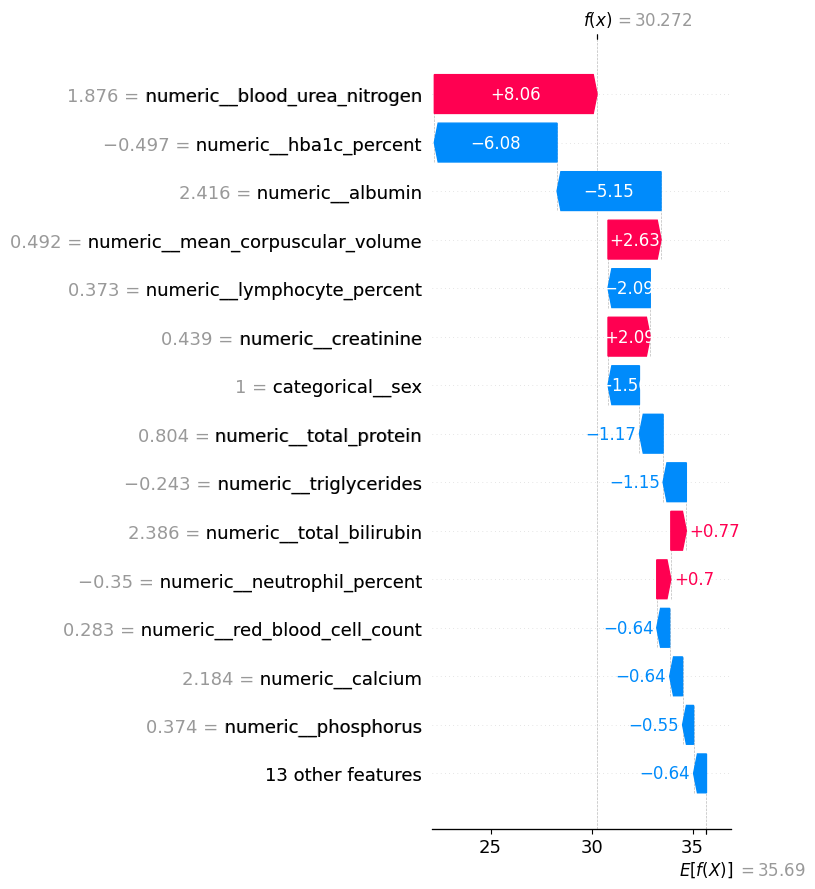

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    waterfall_explanation,
    max_display=15,
    show=False,
)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/shap_waterfall_sample0.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# SHAP Findings

## Objective

The objective of this SHAP analysis was to interpret the tuned XGBoost model, identify the biomarkers driving biological age prediction, and use these insights to guide feature engineering.

---

## Key Findings

### 1. HbA1c is the strongest predictor of biological age.

- HbA1c consistently had the highest SHAP importance.
- Higher HbA1c values generally increased the predicted biological age.
- The dependence plot suggests a threshold-like relationship rather than a purely linear effect.

---

### 2. Multiple physiological systems contribute to biological aging.

The most influential biomarkers represent different biological systems:

- Glucose metabolism (HbA1c)
- Red blood cell physiology (MCV)
- Lipid metabolism (Total Cholesterol)
- Kidney function (Blood Urea Nitrogen)
- Mineral metabolism (Phosphorus)

This suggests the model captures multiple aspects of physiological aging instead of relying on a single biomarker.

---

### 3. Several biomarkers exhibit non-linear relationships.

Dependence plots revealed that biomarkers such as:

- HbA1c
- Mean Corpuscular Volume
- Blood Urea Nitrogen
- Phosphorus

have non-linear effects on model predictions.

This supports the choice of tree-based models (XGBoost), which naturally capture complex non-linear relationships.

---

### 4. Feature interactions are present.

The dependence plots indicate interactions between several biomarkers.

For example:

- HbA1c × Mean Corpuscular Volume
- Total Cholesterol × HbA1c

These interactions suggest that biological age is influenced by combinations of biomarkers rather than isolated variables.

---

### 5. Local explanations improve model transparency.

Waterfall analysis demonstrates how individual biomarkers contribute to a single prediction by either increasing or decreasing the estimated biological age.

This improves model interpretability and provides transparency at the individual prediction level.

---

## Conclusions

The SHAP analysis indicates that the tuned XGBoost model learns biologically meaningful patterns from NHANES laboratory biomarkers.

The identified non-linear relationships and feature interactions will be used to guide the next stage of the project: evidence-based feature engineering.

In [35]:
import pandas as pd
import numpy as np

feature_importance = (
    pd.DataFrame({
        "Feature": X_test_transformed.columns,
        "Mean |SHAP|": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(10)

,Feature,Mean |SHAP|
0,numeric__hba1c_percent,8.158381
1,numeric__mean_corpuscular_volume,4.625555
2,numeric__total_cholesterol,3.408314
3,numeric__blood_urea_nitrogen,2.815649
4,numeric__phosphorus,2.193276
5,numeric__lymphocyte_percent,1.673074
6,numeric__triglycerides,1.535872
7,numeric__red_cell_distribution_width,1.516586
8,numeric__creatinine,1.479436
9,numeric__platelet_count,1.093230


# Next Steps

Based on the SHAP analysis, the next phase of the project will focus on:

- Evaluating biologically meaningful interaction features.
- Testing transformations for biomarkers with strong non-linear relationships.
- Retraining the XGBoost and LightGBM models using engineered features.
- Comparing performance against the current tuned baseline to determine whether feature engineering provides a statistically meaningful improvement.